<a href="https://colab.research.google.com/github/subani1323/Database_Assignment/blob/main/Database_Assignment_Section_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base_url = "https://raw.githubusercontent.com/subani1323/Database_Assignment/main/"

deliveries = pd.read_csv(base_url + "deliveries.csv")
orders = pd.read_csv(base_url + "orders.csv")
hubs = pd.read_csv(base_url + "hubs.csv")

drivers = pd.read_csv(base_url + "drivers.csv")
incidents = pd.read_csv(base_url + "incidents.csv")
customers = pd.read_csv(base_url + "customers.csv")
complaints = pd.read_csv(base_url + "complaints.csv")

print("Deliveries")
display(deliveries.head())

print("Orders")
display(orders.head())

print("Hubs")
display(hubs.head())

Deliveries


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


Orders


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


Hubs


,hub_id,hub_name,zone,hub_type,capacity_score
0,H01,North Exchange,North,Dispatch,82
1,H02,South Link,South,Dispatch,78
2,H03,East Dock,East,Warehouse,74
3,H04,West Gate,West,Dispatch,69
4,H05,Central Core,Central,Control,88


In [ ]:
# Merge deliveries with orders
delivery_orders = pd.merge(deliveries, orders, on="order_id", how="inner")

# Merge with hubs
delivery_orders_hubs = pd.merge(delivery_orders, hubs, on="hub_id", how="inner")

# View result
delivery_orders_hubs.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,Central,CENTRAL,Medium,151.14,Web,0,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,RiverSide,North,Medium,10.04,App,1,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,CENTRAL,NORTH,Medium,141.93,Web,0,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,SOUTH,north,Low,11.11,App,0,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,RiverSide,RiverSide,High,76.02,App,0,North Exchange,North,Dispatch,82


In [ ]:
# Check missing values
print(delivery_orders_hubs.isnull().sum())

# Handle missing values
delivery_orders_hubs["customer_rating_post_delivery"] = delivery_orders_hubs["customer_rating_post_delivery"].fillna(0)
delivery_orders_hubs["fuel_or_charge_cost"] = delivery_orders_hubs["fuel_or_charge_cost"].fillna(0)
delivery_orders_hubs["route_distance_km"] = delivery_orders_hubs["route_distance_km"].fillna(0)

delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
customer_id                       0
service_type                      0
order_created_at                  0
promised_window_hours             0
pickup_zone                       0
dropoff_zone                      0
priority_level                    0
order_value                       0
booking_channel                  21
special_handling_flag             0
hub_name                          0
zone                              0
hub_type                          0
capacity_score                    0
dtype: int64


In [ ]:
import numpy as np

# Basic statistics
print("Mean:", np.mean(delivery_orders_hubs["route_distance_km"]))
print("Median:", np.median(delivery_orders_hubs["route_distance_km"]))
print("Std Dev:", np.std(delivery_orders_hubs["route_distance_km"]))

# Group analysis
hub_analysis = delivery_orders_hubs.groupby("hub_id").agg(
    total_deliveries=("delivery_id", "count"),
    avg_distance=("route_distance_km", "mean"),
    avg_cost=("fuel_or_charge_cost", "mean")
)

print(hub_analysis)

Mean: 13.909315789473684
Median: 12.84
Std Dev: 7.473970019182938
        total_deliveries  avg_distance   avg_cost
hub_id                                           
H01                  136     13.643309  12.755809
H02                  106     14.169151  12.565000
H03                  119     14.515546  12.744202
H04                  127     13.384567  13.167008
H05                  115     14.321652  13.686000
H06                  104     14.412212  13.319231
H07                  115     14.286957  12.922087
H08                  128     12.815469  11.708203


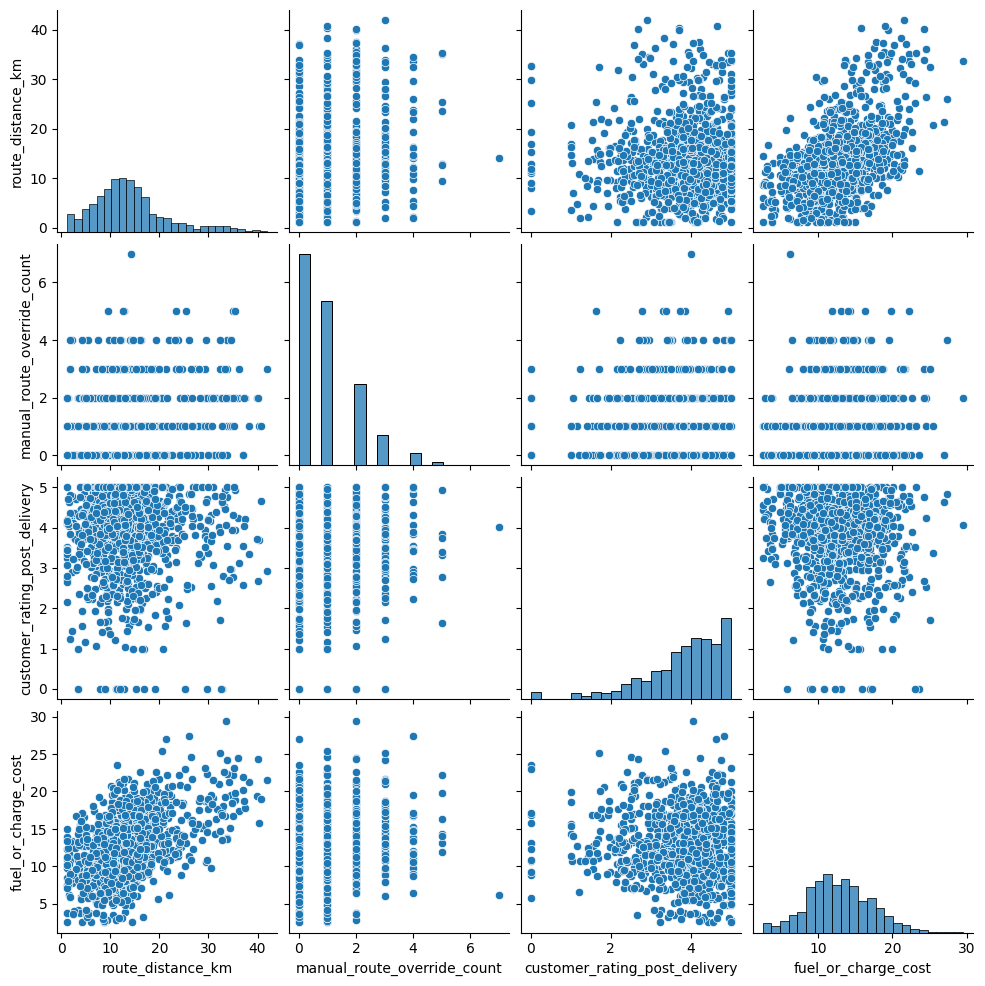

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only relevant numerical columns
cols = [
    "route_distance_km",
    "manual_route_override_count",
    "customer_rating_post_delivery",
    "fuel_or_charge_cost"
]

sns.pairplot(delivery_orders_hubs[cols])
plt.show()

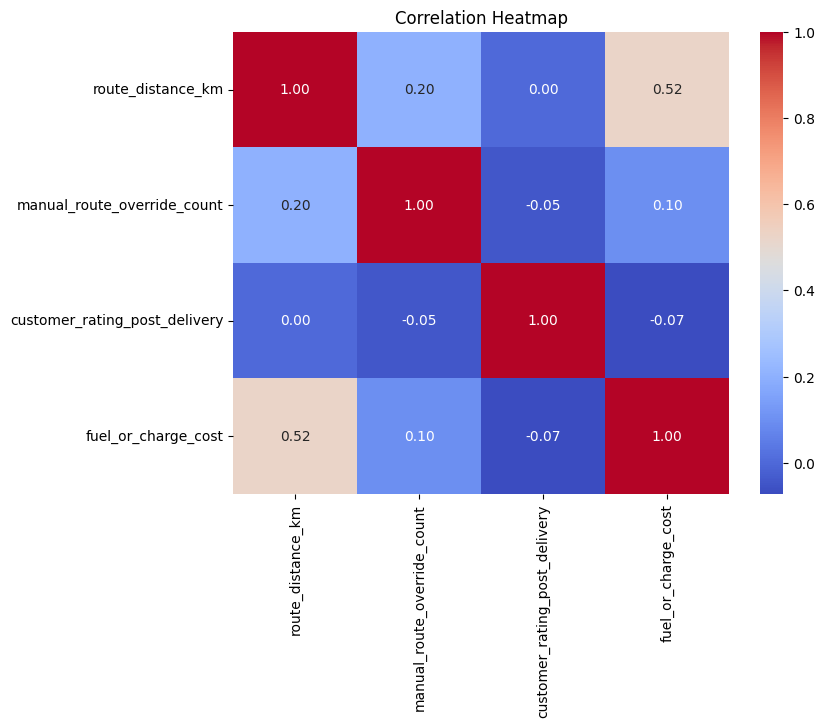

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
numeric_cols = [
    "route_distance_km",
    "manual_route_override_count",
    "customer_rating_post_delivery",
    "fuel_or_charge_cost"
]

# Compute correlation
corr = delivery_orders_hubs[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

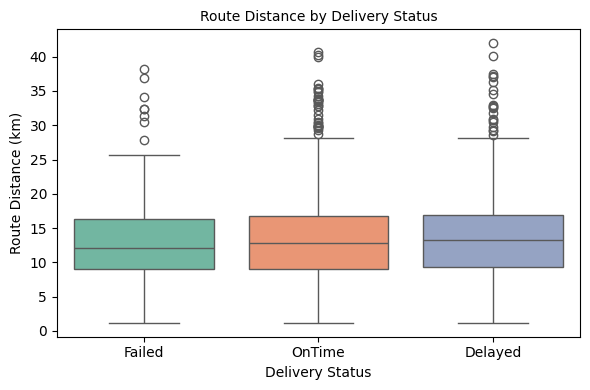

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=delivery_orders_hubs,
    x="delivery_status",
    y="route_distance_km",
    hue="delivery_status",
    palette="Set2",
    legend=False
)

plt.title("Route Distance by Delivery Status", fontsize=10)
plt.xlabel("Delivery Status")
plt.ylabel("Route Distance (km)")

plt.tight_layout()
plt.show()

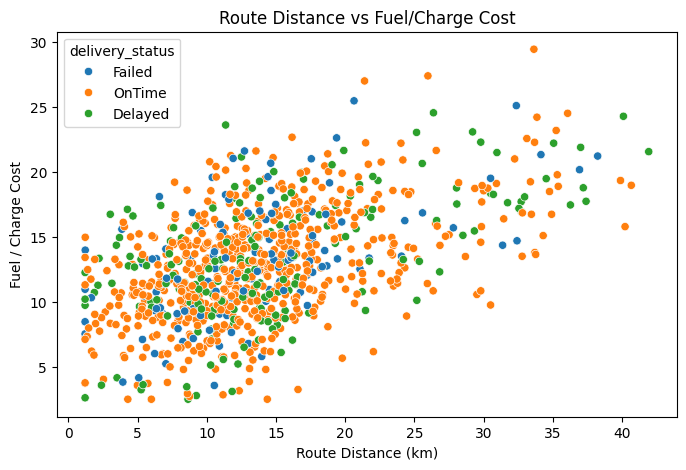

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=delivery_orders_hubs,
    x="route_distance_km",
    y="fuel_or_charge_cost",
    hue="delivery_status"
)

plt.title("Route Distance vs Fuel/Charge Cost")
plt.xlabel("Route Distance (km)")
plt.ylabel("Fuel / Charge Cost")

plt.show()

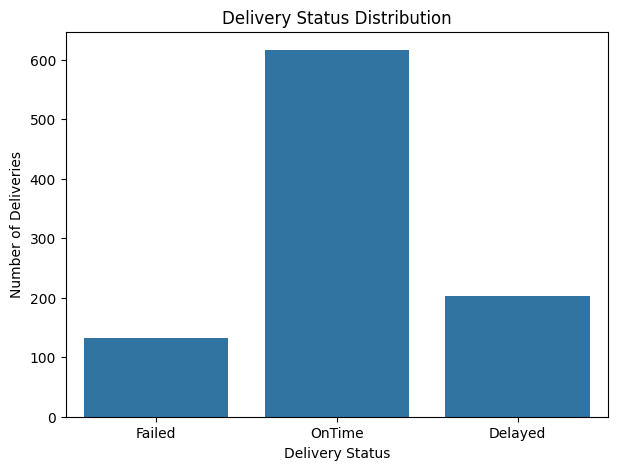

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=delivery_orders_hubs,
    x="delivery_status"
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")

plt.show()

In [ ]:
# Check duplicate rows
duplicate_count = delivery_orders_hubs.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

# Remove duplicate rows
delivery_orders_hubs = delivery_orders_hubs.drop_duplicates()

# Standardize text formatting
delivery_orders_hubs["delivery_status"] = delivery_orders_hubs["delivery_status"].str.strip().str.title()
delivery_orders_hubs["hub_id"] = delivery_orders_hubs["hub_id"].str.strip().str.upper()

# Convert numeric columns
delivery_orders_hubs["route_distance_km"] = pd.to_numeric(
    delivery_orders_hubs["route_distance_km"], errors="coerce"
)

delivery_orders_hubs["fuel_or_charge_cost"] = pd.to_numeric(
    delivery_orders_hubs["fuel_or_charge_cost"], errors="coerce"
)

delivery_orders_hubs["customer_rating_post_delivery"] = pd.to_numeric(
    delivery_orders_hubs["customer_rating_post_delivery"], errors="coerce"
)

# Remove invalid records
delivery_orders_hubs = delivery_orders_hubs[
    delivery_orders_hubs["route_distance_km"] >= 0
]

# Fill missing values
delivery_orders_hubs["fuel_or_charge_cost"] = delivery_orders_hubs["fuel_or_charge_cost"].fillna(0)
delivery_orders_hubs["customer_rating_post_delivery"] = delivery_orders_hubs["customer_rating_post_delivery"].fillna(
    delivery_orders_hubs["customer_rating_post_delivery"].mean()
)

print("Data cleaning completed successfully!")

Duplicate Rows: 0
Data cleaning completed successfully!


In [ ]:
missing_value_table = pd.DataFrame({
    "Column": [
        "fuel_or_charge_cost",
        "customer_rating_post_delivery",
        "route_distance_km"
    ],
    "Missing Values": [
        delivery_orders_hubs["fuel_or_charge_cost"].isnull().sum(),
        delivery_orders_hubs["customer_rating_post_delivery"].isnull().sum(),
        delivery_orders_hubs["route_distance_km"].isnull().sum()
    ],
    "Handling Method": [
        "Replaced with 0",
        "Filled with mean value",
        "Converted to numeric and invalid values removed"
    ]
})

missing_value_table

,Column,Missing Values,Handling Method
0,fuel_or_charge_cost,0,Replaced with 0
1,customer_rating_post_delivery,0,Filled with mean value
2,route_distance_km,0,Converted to numeric and invalid values removed
